In [210]:
from numba import jit, njit
import kwant
from kwant.digest import uniform    # a (deterministic) pseudorandom number generator
import kwant.kpm


import scipy

import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

from scipy.ndimage import gaussian_filter


import cmath

from qutip import *
from joblib import Parallel, delayed

from numba import njit, prange
from numba import set_num_threads, get_num_threads



# --- Labels ---
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}

In [211]:
def gate_U(vx, d):
    UL = 0  #in meV
    UR = 0
    
    vUG = (UR+UL)/2. + (UR-UL)/np.pi*np.arctan(vx/d)
    
    return vUG

def donor_U(vx, d, E0):
    vDonors = np.zeros(len(vx))
    #E0 = 4377 #in meV
    vDonors = - E0 * (1-vx**2/d**2)**.5
    return vDonors
    
def kernel(vx, vt, d):
    l_cut = 2.  #in nm
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    md = d * np.ones(shape=(len(vx), len(vt)))
    mK = np.log( np.abs( (np.sqrt( (d**2 - mx**2.)*(d**2.-mt**2) ) + d**2 - mx*mt )/(2*d**2) ) ) - np.log( np.abs((mx-mt + 1e-12)/(2*d)) )*(1-np.exp(-np.abs(mx-mt)/l_cut ))    
    
    return mK - np.amin(mK)*0

def kernel_1D_image(vx, vt, d, dedge):
    
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    md = d * np.ones(shape=(len(vx), len(vt)))
    mdedge = dedge * np.ones(shape=(len(vx), len(vt)))
    l_cut = 2.  #in nm
        
    #mK = np.log( np.abs( (np.sqrt( (md**2 - mx**2.)*(md**2.-mt**2) ) + d**2 - mx*mt )/(mx-mt + 1e-7)/md ) ) 
    #mK += np.log( np.abs( mx + mt - 2*md - 2*mdedge + 1e-7 ) )
    
    #mK = - ( np.log( np.abs( mx - mt + 1e-7 ) )*(1-np.exp(-np.abs(mx-mt)/l_cut )) - np.log( np.abs( mx + mt - 2*md - 2*mdedge + 1e-7 ) )  ) 
    #mK = - ( np.log( np.abs( mx - mt + 1e-10 ) )*(1-np.exp(-np.abs(mx-mt)/l_cut )) - np.log( np.sqrt( (mx - mt)**2 + (2*mdedge)**2 + 1e-10 ) )  ) 
    mK = - np.log( np.abs( mx - mt + 1e-12 ) )*(1-np.exp(-np.abs(mx-mt)/l_cut )) + np.log( np.abs( mx + mt - 2*md - 2*mdedge + 1e-12 ) ) + 0*np.log( np.sqrt( (mx - mt)**2 + (2*3400)**2 + 1e-10 ) )   
    
    return mK - np.amin(mK)

def kernel_1D_0(vx, vt, d):
    
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    md = d * np.ones(shape=(len(vx), len(vt)))
    l_cut = 1  #in nm
    mK = - np.log( np.abs( mx - mt + 1e-12 )/(d) )*(1-np.exp(-np.abs(mx-mt)/l_cut ))    
    
    return mK - np.amin(mK)

def kernel_3D(vx, vt, d, sides, dedge):
    
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    mK = np.zeros(shape=(len(vx), len(vt)))
    
    l_cut = .1  #in nm
    if sides == 2:
        for m in range(-100,100):
            mK += (1./np.abs( mx - mt - 4*d*m + 1e-7 ) - 1./np.abs( mx + mt + 2*d - 4*d*m + 1e-7 ) ) * (1-np.exp(-np.abs(mx-mt)/l_cut ))   #smooth UV cutoff at l_cut in nm
    elif sides == 1:
        #m = 1
        #mK = (1./np.abs( mx - mt + 1e-7 ) - 1./np.abs( mx + mt + 2*d - 4*d*m + 1e-7 ) ) * (1-np.exp(-np.abs(mx-mt)/l_cut ))   #smooth UV cutoff at l_cut in nm
        
        #mK = (1./np.abs( mx - mt + 1e-7 ) - 1./np.abs( mx + mt + 2*d + 2*dedge + 1e-7 ) ) * (1-np.exp(-np.abs(mx-mt)/l_cut ))   #smooth UV cutoff at l_cut in nm   LEFT
        mK = (1./np.abs( mx - mt + 1e-7 )* (1-np.exp(-np.abs(mx-mt)/l_cut )) - 1./np.abs( mx + mt - 2*d - 2*dedge + 1e-7 ) )   #smooth UV cutoff at l_cut in nm      RIGHT
    elif sides == 0:
        m = 1
        mK = (1./np.abs( mx - mt + 1e-7 ) ) * (1-np.exp(-np.abs(mx-mt)/l_cut ))   #smooth UV cutoff at l_cut in nm
    return mK - np.amin(mK)

def int_donor_U(vx, d, mK, n0, U0):
    vDonors = np.zeros(len(vx))
    dx = np.abs(vx[0]-vx[1])
    vDonors = - np.sum(mK, axis=1)*dx *n0*U0
    return vDonors

def int_nonhomo_donor_U(vx, d, mK, n0, U0):
    vDonors = np.zeros(len(vx))
    dx = np.abs(vx[0]-vx[1])
    vDonors = - np.dot(mK, n0)*dx *U0
    return vDonors

def dos_B( B, vE, gam0 ):
    lB = 25/B**.5   #in nm and B in T
    omB = 1.76 * B  #in meV and B in T
    EZ = omB/3.
    Gam = gam0 * omB * (10/B)**.5
    vD = np.zeros( len(vE) )
    for n in range(150):
        epsn = (.5+n)*omB
        vD += 1./(2*np.pi*lB**2.) * ( np.exp( - (epsn - vE)**2./Gam**2. )/(np.pi*Gam**2.)**.5 + np.exp( - (epsn+EZ - vE)**2./Gam**2. )/(np.pi*Gam**2.)**.5 )
    
    return vD

@njit
def number_e(T, vx, vU, vD, vE, mu):    #T in meV
    num_e = np.zeros(len(vx))
    
    dE = np.abs(vE[0]-vE[1])
    
    for ne, E in enumerate(vE):
        F = 1./( np.exp( (E + vU - mu)/T ) + 1. )
        num_e += dE*vD[ne] * F
    
    return num_e

@njit
def dmu_dnumber_e(T, vx, vU, vD, vE, mu):    #T in meV
    dnum_e = np.zeros(len(vx))
    
    dE = np.abs(vE[0]-vE[1])
    
    for ne, E in enumerate(vE):
        dF = 1./( np.exp( (E + vU - mu)/T ) + 1. )**2. * np.exp( (E + vU - mu)/T )/T
        dnum_e += dE*vD[ne] * dF
    
    return dnum_e

@njit
def ddddmu_dnumber_e(T, vx, vU, vD, vE, mu):    #T in meV
    dnum_e = np.zeros(len(vx))
    
    dE = np.abs(vE[0]-vE[1])
    if T > 1.:
        for ne, E in enumerate(vE):
            dF = 1./( np.exp( (E + vU - mu)/T ) + 1. )**2. * np.exp( (E + vU - mu)/T )/T
            dnum_e += dE*vD[ne] * dF
    else:
        for nx, x in enumerate(vx):
            ne = np.argmin(np.abs(vE - (mu - vU[nx] ) ))
            dnum_e[nx] = vD[ne]
    
    return dnum_e

In [212]:
def load_Ux(filename):
    # ---- Read numerical columns ----
    data = np.loadtxt(filename)

    vx     = data[:, 0]
    vU     = data[:, 1]
    vnum_e = data[:, 2]
    dnum_e = data[:, 3]

    # ---- Read metadata from header ----
    mu  = None
    omB = None

    with open(filename, "r") as f:
        for line in f:
            if "mu =" in line:
                mu = float(line.split("=")[1])
            if "omB =" in line:
                omB = float(line.split("=")[1])

    return vx, vU, vnum_e, dnum_e, mu, omB

vx, vU, vnum_e, dnum_e, mu, omB = load_Ux("Ux.dat")
print(mu/omB)
T = .011 #in meV 0.01 => 0.116 K
gam0 = 0.01  #adimensional width of the LLs

#B = 1.95
#omB = 1.76*B

B = omB/1.76
lB = 25/B**.5   #in nm


d = 2000   #in nm


vt = vx.copy()
mK = kernel(vx, vt, d)

vE = np.linspace(.0001, 6, 5000) * omB
vD = dos_B( B, vE, gam0 )

targ_num_e = 2.5 * 1e-3     #in nm^-2 ---> 10^-3 nm^-2 = 10^11 cm^-2
num_D = targ_num_e * 3.5

kappa0 = 1.44/13. * 10e3  #in meV * nm


dx = np.abs(vx[1]-vx[0])
vUD = int_nonhomo_donor_U(vx, d, mK, num_D*np.ones(len(vx)), kappa0)

5.502584704249271


(-1.0, 1.0)

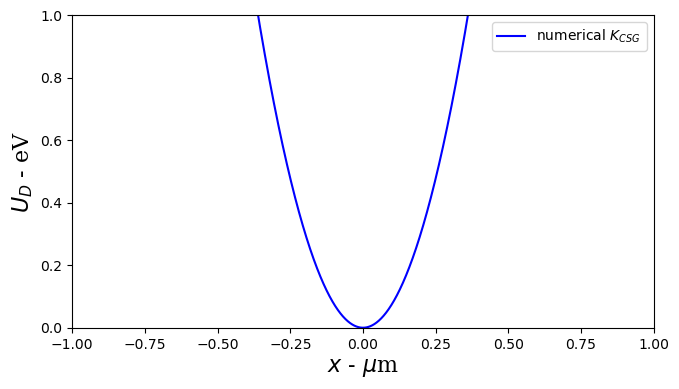

In [213]:
plt.plot(vx*1e-3, (vUD-np.amin(vUD))*1e-3, color='blue', label=r'numerical $K_{CSG}$')
plt.xlabel(r"$x$ - $\mu$m", fontdict=font)
plt.ylabel(r"$U_D$ - eV", fontdict=font)
plt.legend()
plt.gcf().set_size_inches(170 / 25.4, 100 / 25.4)
plt.tight_layout()
plt.ylim(0,1.)
plt.xlim(-1,1)

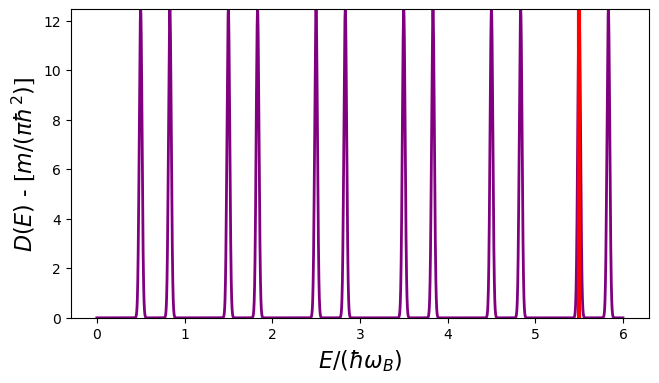

In [214]:
plt.plot(vE/omB, np.pi*lB**2*omB*vD, color='purple', linewidth=2)
plt.vlines(mu/omB, ymin=0, ymax=np.amax(np.pi*lB**2*omB*vD), color='red', linewidth=3)
plt.ylim(0,np.pi*lB**2*omB*np.amax(vD))

plt.xlabel(r"$E/(\hbar\omega_B)$", fontdict=font)
plt.ylabel(r"$D(E)$ - [$m/(\pi \hbar^2)$]", fontdict=font)
#plt.legend()
plt.gcf().set_size_inches(170 / 25.4, 100 / 25.4)
plt.tight_layout()
plt.savefig("DOS_mu.pdf")

In [215]:
vU = gaussian_filter(vU, sigma=2)
vnum_e = gaussian_filter(vnum_e, sigma=2)

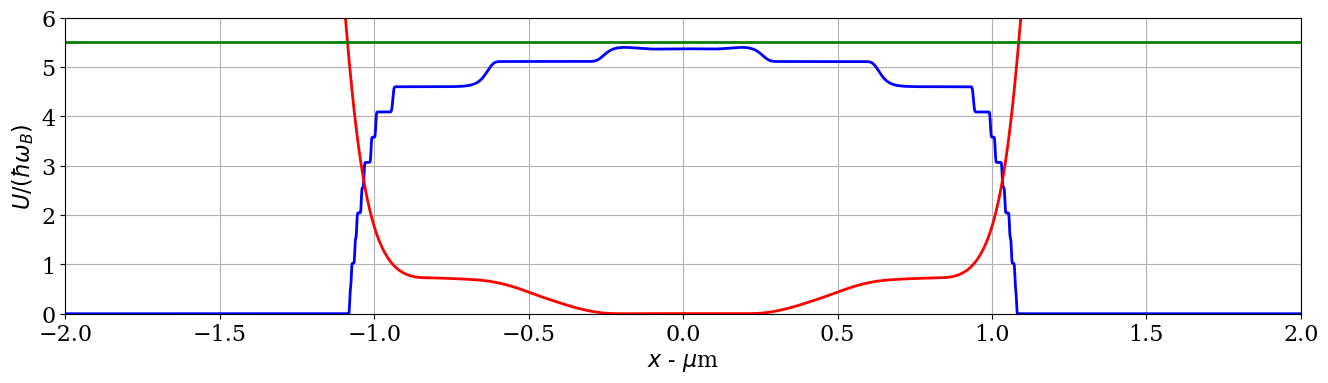

In [216]:
ymax = 6
plt.plot( vx*1e-3, vnum_e/np.amax(vnum_e)*ymax*9./10., color='blue', linewidth=2 )
#plt.plot(vx, vU/omB + 1e1*np.log(np.abs( (vx-1600)/1000 ))*np.exp(-np.abs( (vx-1600)/1000) ), color='red', linewidth=2)
plt.plot(vx*1e-3, vU/omB , color='red', linewidth=2)
plt.hlines(mu/omB, xmin=-d, xmax=d, color='green', linewidth=2)
#plt.plot(vx, vUD/omB, linestyle='--')
plt.ylim(0,ymax)
plt.xlim(-d*1e-3,d*1e-3)

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
plt.xlabel(r"$x$ - $\mu$m", fontdict=font)
plt.ylabel(r"$U/(\hbar \omega_B)$", fontdict=font)
# Customize tick labels
plt.xticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.grid()

plt.gcf().set_size_inches(340 / 25.4, 100 / 25.4)
plt.tight_layout()

In [217]:
import numpy as np
from numba import njit, prange

@njit(fastmath=True)
def number_e_out(out, T, vU, vD, vE, mu):
    out[:] = 0.0
    dE = abs(vE[0] - vE[1])
    for ne in range(vE.size):
        E = vE[ne]
        F = 1.0 / (np.exp((E + vU - mu) / T) + 1.0)   # keep vectorized form
        out += dE * vD[ne] * F

@njit(parallel=True, fastmath=True)
def compute_avg_num_e_out(avg_num_e, list_num_e, arr_mu, T, vx, vU, vD, vE, d):
    dx = abs(vx[0] - vx[1])
    n_mu = arr_mu.size
    for i in prange(n_mu):
        number_e_out(list_num_e[i], T, vU, vD, vE, arr_mu[i])
        avg_num_e[i] = dx * list_num_e[i].sum() / (2.0 * d)

@njit(fastmath=True)
def self_cons_prealloc_thin(T, d, vx, vD, vE, mu0, targ_num_e, kappa0, mK, vU, vUD, vUG, iterations, stride):
    alpha = 5e-8
    dx = abs(vx[0] - vx[1])

    n_log = (iterations + stride - 1) // stride
    v_mu = np.empty(n_log)
    v_num_e = np.empty(n_log)

    # scratch
    n_mu = 10
    arr_mu = np.empty(n_mu)
    avg_num_e = np.empty(n_mu)
    list_num_e = np.empty((n_mu, vx.size))

    vnum_e_old = np.empty(vx.size)
    vnum_e = np.empty(vx.size)

    mu = mu0
    dmu_r = .00001
    number_e_out(vnum_e_old, T, vU, vD, vE, mu)

    scale = kappa0 * dx
    bias = vUD + vUG  # precompute once

    logi = 0
    for ni in range(iterations):
        for i in range(n_mu):
            t = -dmu_r/2. + dmu_r * i / (n_mu - 1)
            arr_mu[i] = mu + t * mu

        compute_avg_num_e_out(avg_num_e, list_num_e, arr_mu, T, vx, vU, vD, vE, d)

        best_i = 0
        best_err = abs(avg_num_e[0] - targ_num_e)
        for i in range(1, n_mu):
            err = abs(avg_num_e[i] - targ_num_e)
            if err < best_err:
                best_err = err
                best_i = i

        mu = arr_mu[best_i]
        vnum_e[:] = list_num_e[best_i]

        diff = vnum_e_old - vnum_e
        err2 = dx * (diff * diff).sum()
        vnum_e_old[:] = vnum_e

        # in-place-ish update (avoid extra temporaries)
        vUnew = scale * np.dot(mK, vnum_e) + bias
        vUnew -= vUnew.min()

        vU = alpha * vUnew + (1.0 - alpha) * vU
        vU -= vU.min()

        if (ni % stride) == 0:
            v_mu[logi] = mu
            v_num_e[logi] = err2
            logi += 1

    return v_mu, v_num_e, vU, vnum_e


@njit(fastmath=True)
def self_cons_prealloc(T, d, vx, vD, vE, mu0, targ_num_e, kappa0, mK, vU, vUD, vUG, iterations):
    alpha = 2.5e-6
    dx = abs(vx[0] - vx[1])

    v_mu = np.empty(iterations)
    v_num_e = np.empty(iterations)

    # --- preallocate scratch once ---
    n_mu = 20
    arr_mu = np.empty(n_mu)
    avg_num_e = np.empty(n_mu)
    list_num_e = np.empty((n_mu, vx.size))  # reuse this every iteration

    vnum_e_old = np.empty(vx.size)
    vnum_e = np.empty(vx.size)

    mu = mu0
    dmu_r = .01
    number_e_out(vnum_e_old, T, vU, vD, vE, mu)

    for ni in range(iterations):
        # fill arr_mu without allocating linspace
        for i in range(n_mu):
            t = -dmu_r/2. + dmu_r * i / (n_mu - 1)
            arr_mu[i] = mu + t * mu

        compute_avg_num_e_out(avg_num_e, list_num_e, arr_mu, T, vx, vU, vD, vE, d)

        # argmin |avg - target|
        best_i = 0
        best_err = abs(avg_num_e[0] - targ_num_e)
        for i in range(1, n_mu):
            err = abs(avg_num_e[i] - targ_num_e)
            if err < best_err:
                best_err = err
                best_i = i

        mu = arr_mu[best_i]
        v_mu[ni] = mu

        vnum_e[:] = list_num_e[best_i]

        diff = vnum_e_old - vnum_e
        v_num_e[ni] = dx * (diff * diff).sum()
        vnum_e_old[:] = vnum_e

        vUnew = kappa0 * dx * np.dot(mK, vnum_e) + vUD + vUG
        vUnew -= vUnew.min()

        vU = alpha * vUnew + (1.0 - alpha) * vU
        vU -= vU.min()

    return v_mu, v_num_e, vU, vnum_e

In [218]:
iterations = 1000
#v_mu, v_num_e, vU, vnum_e = self_cons_prealloc(T, d, vx, vD, vE, mu, targ_num_e, kappa0, mK, vU, vUD, vUG, iterations)
v_mu, v_num_e, vU, vnum_e = self_cons_prealloc_thin(T, d, vx, vD, vE, mu, targ_num_e, kappa0, mK, vU, vUD, np.zeros(len(vUD)), iterations, int(iterations/20))

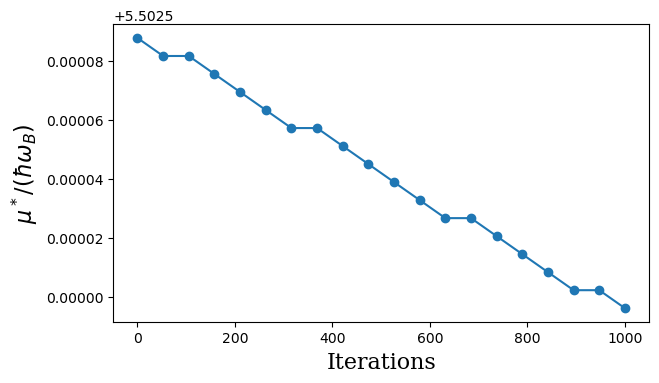

In [219]:

plt.plot(np.linspace(0,iterations, len(v_mu)), v_mu/omB, marker='o')
plt.xlabel(r"Iterations", fontdict=font)
plt.ylabel(r"$\mu^*/(\hbar \omega_B)$", fontdict=font)
#plt.legend()
plt.gcf().set_size_inches(170 / 25.4, 100 / 25.4)
plt.tight_layout()
plt.savefig("conv_mu.pdf")

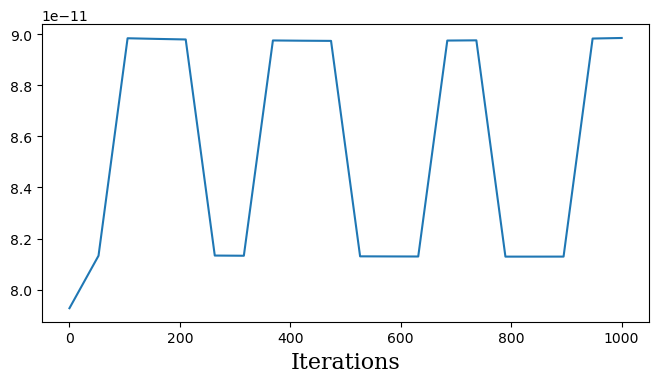

In [220]:
#plt.plot(np.linspace(0,iterations, iterations), 100*np.abs(v_num_e/(v_num_e[-1])-1.) )
plt.plot(np.linspace(0,iterations, len(v_num_e)), 100*np.abs(v_num_e ) )
#plt.plot(np.linspace(0,iterations-1, iterations-1), 100*np.abs( (v_num_e[1:iterations]-v_num_e[0:iterations-1])/(v_num_e[1:iterations]+v_num_e[0:iterations-1] )) )
#plt.yscale('log')
plt.xlabel(r"Iterations", fontdict=font)
#plt.ylabel(r"$|\delta \bar{n}_e/\bar{n}_e - 1|$  %", fontdict=font)
#plt.ylabel(r"$|\bar{n}_e^{(j+1)}-\bar{n}_e^{(j)}|/|\bar{n}_e^{(j+1)}+\bar{n}_e^{(j)}|$  %", fontdict=font)
#plt.legend()
plt.gcf().set_size_inches(170 / 25.4, 100 / 25.4)
plt.tight_layout()

plt.savefig("conv_esti.pdf")


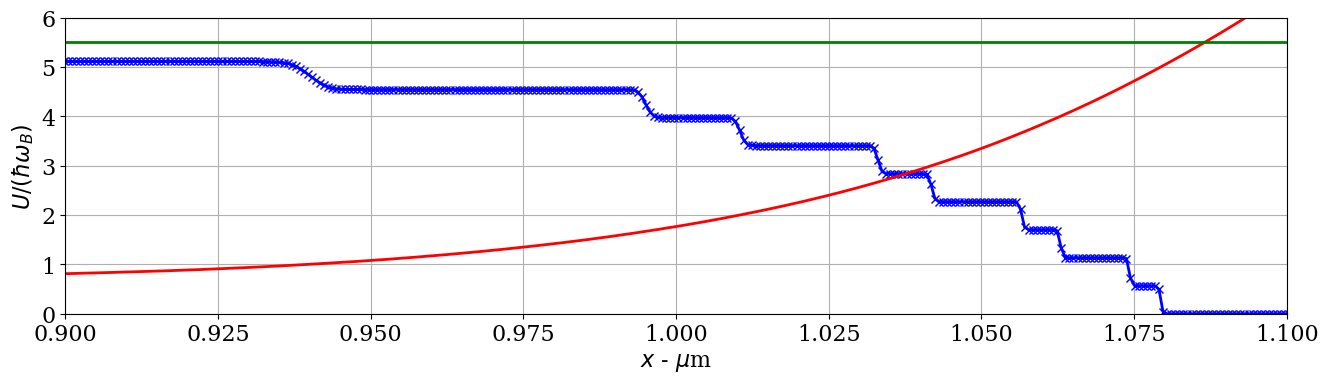

In [221]:
ymax = 6
plt.plot( vx*1e-3, vnum_e/np.amax(vnum_e)*ymax*10./10., color='blue', linewidth=2, marker='x' )
#plt.plot(vx, vU/omB + 1e1*np.log(np.abs( (vx-1600)/1000 ))*np.exp(-np.abs( (vx-1600)/1000) ), color='red', linewidth=2)
plt.plot(vx*1e-3, vU/omB , color='red', linewidth=2)
plt.hlines(v_mu[-1]/omB, xmin=-d, xmax=d, color='green', linewidth=2)
#plt.plot(vx, vUD/omB, linestyle='--')
plt.ylim(0,ymax)
#plt.xlim(-d*1e-3,d*1e-3)
plt.xlim(.9,1.1)

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
plt.xlabel(r"$x$ - $\mu$m", fontdict=font)
plt.ylabel(r"$U/(\hbar \omega_B)$", fontdict=font)
# Customize tick labels
plt.xticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.grid()

plt.gcf().set_size_inches(340 / 25.4, 100 / 25.4)
plt.tight_layout()

#plt.savefig("eff_conf.pdf")

In [222]:
print(targ_num_e, np.sum(vnum_e)*dx/(2.*d))

0.0025 0.002500005420960986


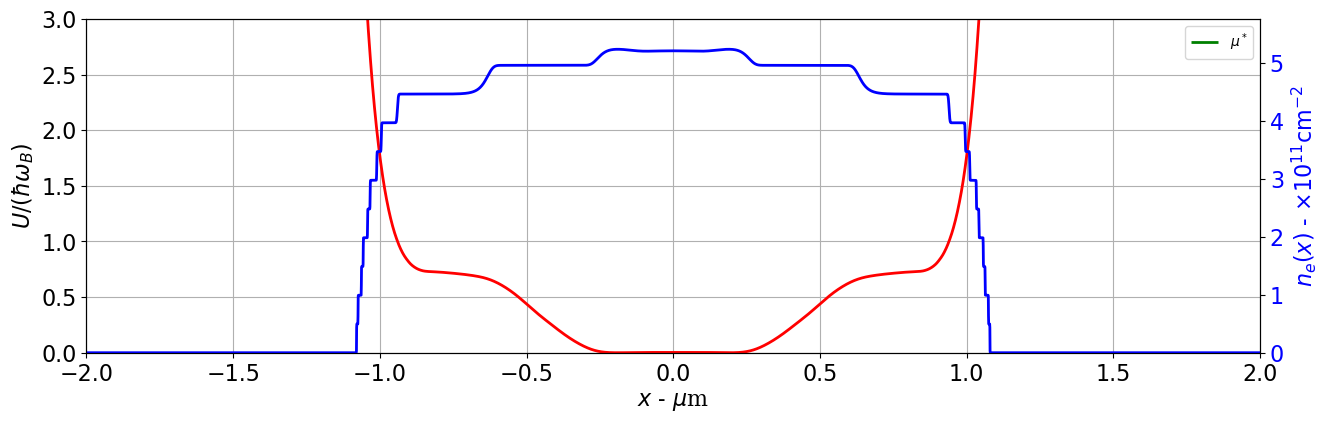

In [223]:
ymax = 3

fig, ax = plt.subplots()

# --- LEFT Y-AXIS (potential) ---
ax.plot(vx*1e-3, vU/omB, color='red', linewidth=2)
ax.hlines(v_mu[-1]/omB, xmin=-d*1e-3, xmax=d*1e-3,
          color='green', linewidth=2, label=r"$\mu^*$")

ax.set_ylim(0, ymax)
ax.set_xlim(-d*1e-3, d*1e-3)

# --- RIGHT Y-AXIS (blue curve) ---
ax2 = ax.twinx()
ax2.plot(
    vx*1e-3,
    vnum_e*1e3,
    color='blue',
    linewidth=2
)

ax2.set_ylim(0, np.amax(vnum_e*1e3)*1.1)   # same scale for visual alignment
ax2.tick_params(axis='y', labelcolor='blue')



ax.set_xlabel(r"$x$ - $\mu$m", fontdict=font)
ax.set_ylabel(r"$U/(\hbar \omega_B)$", fontdict=font)
ax2.set_ylabel(r"$n_e(x)$ - $\times 10^{11} {\rm cm}^{-2}$", fontdict=font, color='blue')

# --- Tick styling ---
ax.tick_params(axis='both',
               labelsize=font['size'],
               labelcolor=font['color'])
ax2.tick_params(axis='y',
                labelsize=font['size'],
                labelcolor='blue')

ax.grid()
ax.legend()

# --- Figure size ---
fig.set_size_inches(340 / 25.4, 110 / 25.4)
fig.tight_layout()

plt.savefig("U_CSG1.pdf")


In [224]:
def ffddddmu_dnumber_e(T, vx, vU, vD, vE, mu):    #T in meV
    dnum_e = np.zeros(len(vx))
    
    dE = np.abs(vE[0]-vE[1])
    zpE = .5*omB*0
    if T > .01:
        for ne, E1 in enumerate(vE):
            E = E1 - zpE
            #dF = np.exp( (E + vU - mu)/T ) /( np.exp( (E + vU - mu)/T ) + 1. )**2./T 
            logdFT = ( (E + vU - mu)/T ) - np.log( np.exp( (E + vU - mu)/T ) + 1. )*2.
            dF = np.exp(logdFT)/T
            dnum_e += dE*vD[ne] * dF
    else:
        for nx, x in enumerate(vx):
            ne = np.argmin(np.abs(vE- zpE - (mu - vU[nx] ) ))
            dnum_e[nx] = vD[ne]
    
    return dnum_e

dnum_e = ffddddmu_dnumber_e(T, vx, vU, vD, vE, mu)


/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_75923/2635813459.py:10: RuntimeWarning: overflow encountered in exp
  logdFT = ( (E + vU - mu)/T ) - np.log( np.exp( (E + vU - mu)/T ) + 1. )*2.


/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_75923/2635813459.py:10: RuntimeWarning: overflow encountered in exp
  logdFT = ( (E + vU - mu)/T ) - np.log( np.exp( (E + vU - mu)/T ) + 1. )*2.


1.006756096928679


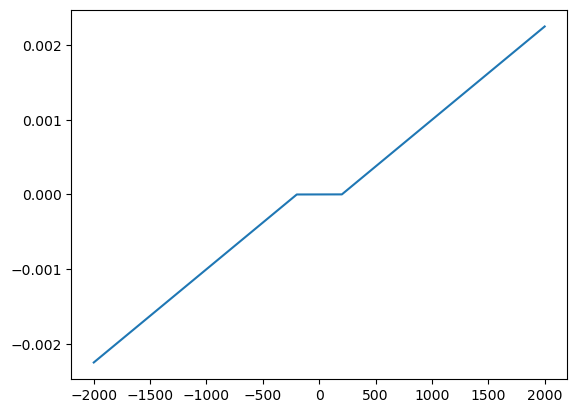

In [225]:
#vnum_e = number_e(T, vx, vU, vD, vE, mu)
#dnum_e = ddddmu_dnumber_e(T, vx, vU, vD, vE, mu)
dnum_e = ffddddmu_dnumber_e(T, vx, vU, vD, vE, v_mu[-1])
dnum_e = gaussian_filter(dnum_e, sigma=2)

#mK_1D = kernel_1D_image(vx, vt, d, 10000)

mKcomp = mK


#dnum_e = number_e(T, vx, vU, vD, vE, mu)

matrix0 = - kappa0 * dx * np.multiply(mKcomp , dnum_e[np.newaxis, :])

matrix_inv = np.eye(len(vx)) -  kappa0 * dx * np.multiply(mKcomp , dnum_e[np.newaxis, :])
MMmatrix = scipy.linalg.inv(matrix_inv)
#MMmatrix = np.eye(len(vx))

UH = .001
delta_mu = np.zeros(len(vx))
dddmu = .1
mask1 = vx > d*dddmu
mask2 = vx < -d*dddmu
delta_mu[mask1] = UH * (vx[mask1]-d*dddmu)/(2*d*.2)
delta_mu[mask2] = UH * (vx[mask2]+d*dddmu)/(2*d*.2)



#dU = - UH * kappa0 * dx * np.dot(mK, np.multiply(vx/(2*d), dnum_e ) )
dU = -  kappa0 * dx * np.dot(mKcomp, np.multiply(delta_mu, dnum_e ) )
dU = np.matmul(MMmatrix, dU)

print(np.amax(np.abs(MMmatrix)))

plt.plot(vx, delta_mu)


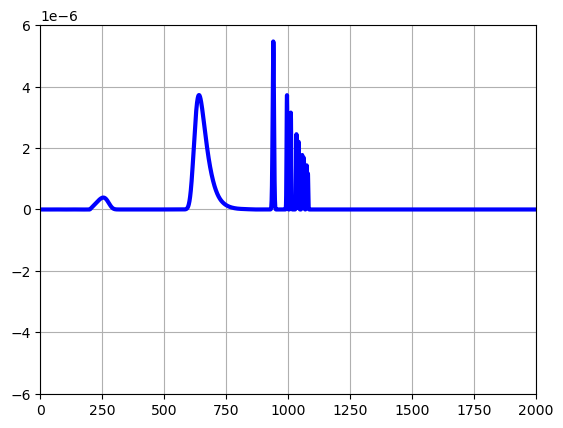

In [226]:
#plt.ylim(-.1,.0)
#plt.xlim(00,1000)
delta_num_e = np.multiply(dnum_e, (delta_mu + dU) )

#plt.plot( vx, (dU)/omB, color='red', linewidth=3 )
plt.plot( vx, delta_num_e, color='blue', linewidth=3 )

#plt.plot( vx, (vU)/omB, color='blue', linewidth=1, linestyle='--' )

plt.xlim(0,2000)
plt.grid()

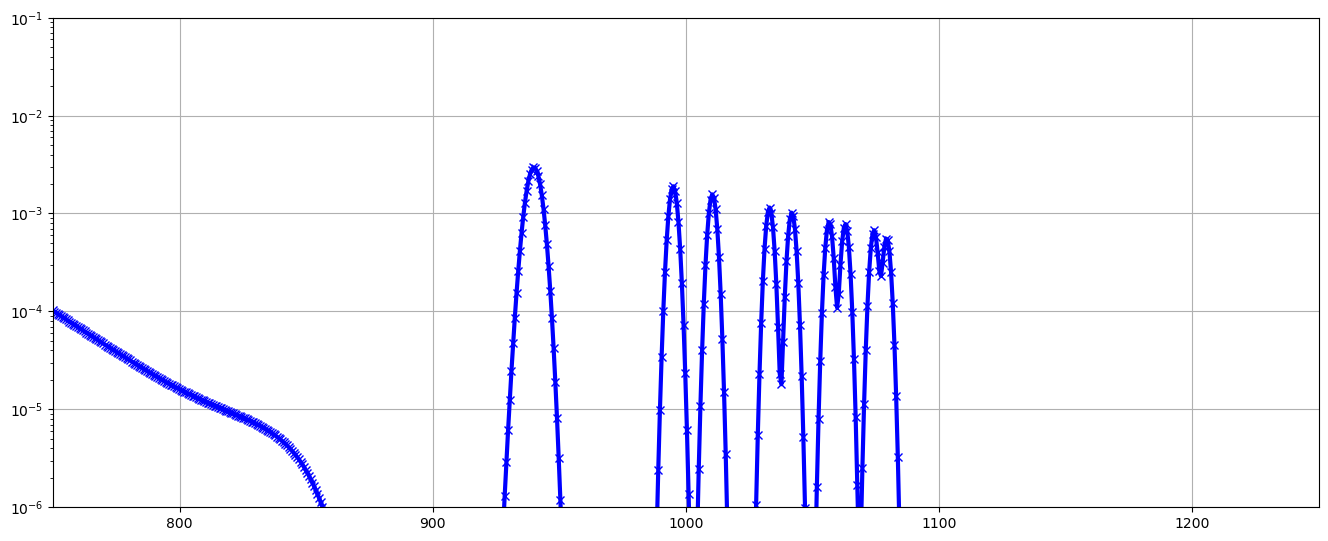

In [227]:
#delta_num_e = np.multiply(dnum_e, - UH*vx/(2*d) + dU )

plt.plot( vx, dnum_e, color='blue', linewidth=3, marker='x' )

plt.yscale('log')
plt.ylim(1e-6,1e-1)
plt.xlim(750,1250)

plt.grid()

plt.gcf().set_size_inches(340 / 25.4, 140 / 25.4)
plt.tight_layout()

0.19390684430461191


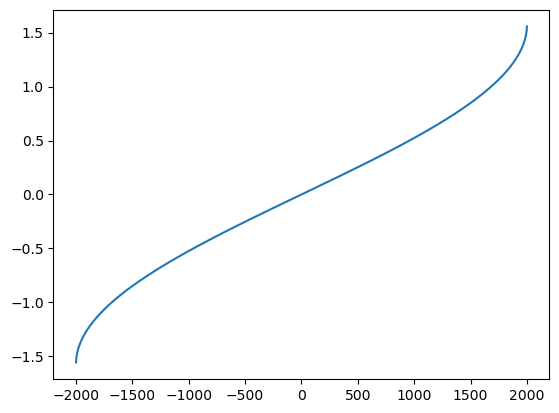

In [228]:
Tfun = np.arctan(np.sqrt((d+vx)/(d-vx) ) ) - np.arctan(np.sqrt((d-vx)/(d+vx) ) )
plt.plot(vx,Tfun)

Vhall = 2/np.pi*kappa0 * np.sum( delta_num_e*Tfun )*dx
print(Vhall)

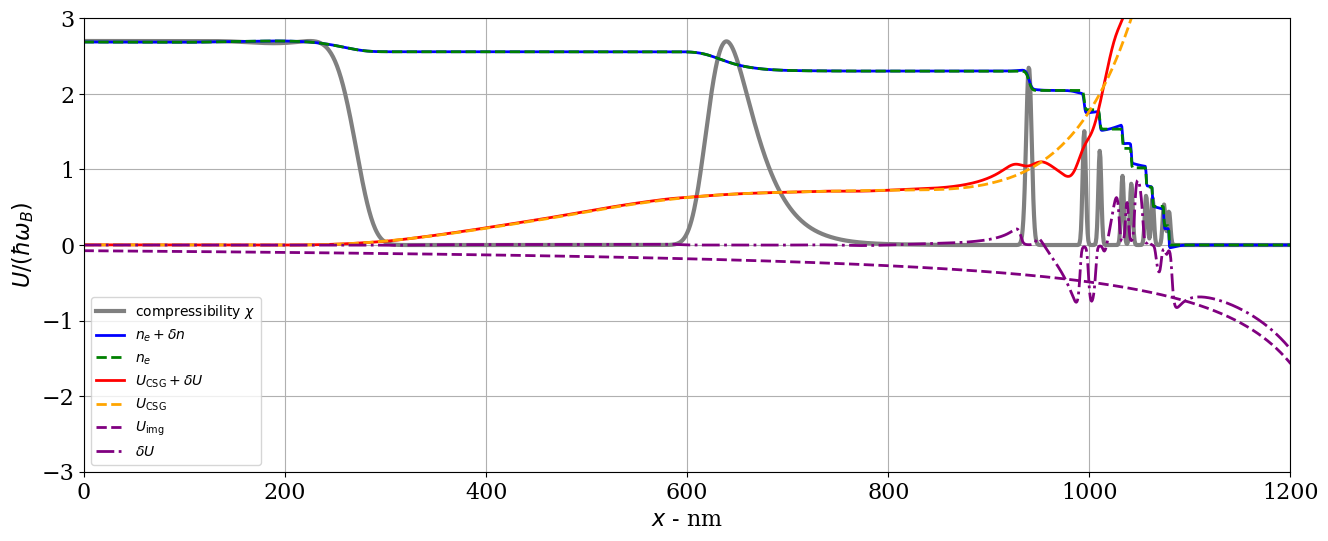

In [229]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.ndimage import gaussian_filter

ymax = 3


#tot_num_e = vnum_e + np.multiply(dnum_e, - UH*vx/(2*d) + dU )
dmetal = 200
ne_1s = 1./(lB) * 1e-0  #1D electron density ( multiplied by scaling factor lB/L_distance )
Uimg_cond = -kappa0/2./np.abs(vx-1300) 
#Uimg_cond = kappa0*np.log( np.abs( (np.sqrt( (d**2 - vx**2.)*(d**2.-vx**2) ) + d**2 - vx*vx )/(2*d**2) ) ) * ne_1s
#x_QH = 1200
#Uimg_cond = kappa0*np.log( np.abs( (np.sqrt( (d**2 - vx**2.)*(d**2.-x_QH**2) ) + d**2 - x_QH*vx )/(2*d**2) ) ) * ne_1s

Uimg_cond = Uimg_cond - np.amax(Uimg_cond)

Uimg_screen = np.matmul(MMmatrix, Uimg_cond) 

smoothing = 10
smoothUimg_screen = gaussian_filter(Uimg_screen, sigma=smoothing)
delta_N = dnum_e * Uimg_screen

smoothN = gaussian_filter(delta_N, sigma=smoothing)

smoothU = gaussian_filter(vU + Uimg_screen, sigma=smoothing)
#smoothU = gaussian_filter(vU - np.matmul(matrix0,Uimg_screen) + Uimg_cond, sigma=smoothing)

#smoothU = vU*0+Uimg_screen



plt.plot( vx, dnum_e/(np.amax(dnum_e))*ymax*9./10., color='grey', linewidth=3, label=r'compressibility $\chi$' )


plt.plot( vx, (vnum_e+smoothN)/np.amax(vnum_e-smoothN)*ymax*9./10., color='blue', linewidth=2, label=r'$n_e+\delta n$' )
plt.plot( vx, (vnum_e)/np.amax(vnum_e)*ymax*9./10., color='green', linestyle='--', linewidth=2 , label=r'$n_e$')

#plt.plot(vx, vU/omB + 1e1*np.log(np.abs( (vx-1600)/1000 ))*np.exp(-np.abs( (vx-1600)/1000) ), color='red', linewidth=2)
#plt.plot(vx, (vU+dU)/omB , color='red', linewidth=2)
plt.plot(vx, (smoothU)/omB , color='red', linewidth=2, label=r'$U_{\rm CSG}+\delta U$')
plt.plot(vx, (vU)/omB , color='orange', linewidth=2, linestyle='--', label=r'$U_{\rm CSG}$')

plt.plot(vx, (Uimg_cond)/omB , color='purple', linewidth=2, linestyle='--', label=r'$U_{\rm img}$')
plt.plot(vx, (Uimg_screen)/omB , color='purple', linewidth=2, linestyle='-.', label=r'$\delta U$')






#plt.hlines(v_mu[-1]/omB, xmin=-d, xmax=d, color='green', linewidth=2)




plt.ylim(-3.,ymax)
plt.xlim(0,1200)

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
plt.xlabel(r"$x$ - nm", fontdict=font)
plt.ylabel(r"$U/(\hbar \omega_B)$", fontdict=font)
# Customize tick labels
plt.xticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.grid()

plt.legend()

plt.gcf().set_size_inches(340 / 25.4, 140 / 25.4)
plt.tight_layout()


"""
ax = plt.gca()
# --- inset: right side, vertically centered ---
axins = inset_axes(
    ax,
    width="35%", height="45%",              # size of inset (tweak as you like)
    loc="center left",                     # right side, centered vertically
    borderpad=1.2
)

# plot ONLY the red curve in the inset (or add the blue too if you want)
axins.plot(vx, (smoothU)/omB, color="red", linewidth=2)
axins.plot(vx, (vU)/omB, color="green", linewidth=2, linestyle='--')


# zoom limits
axins.set_xlim(3000, 4000)
axins.set_ylim(0., 1.2)

# optional: make inset cleaner
axins.grid(True, alpha=0.4)
axins.tick_params(labelsize=10)

# optional: draw a box on the main plot showing the zoomed region + connectors
#mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4")
"""

plt.savefig("U_perturb1.pdf")


(0.001, 10.0)

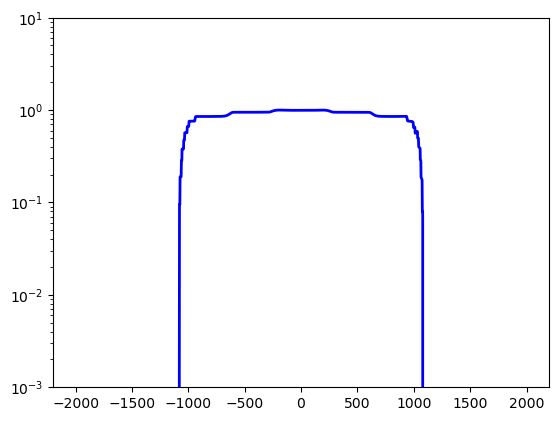

In [230]:
plt.plot( vx, (vnum_e+smoothN)/np.amax(vnum_e-smoothN), color='blue', linewidth=2, label=r'$n_e+\delta n_{\rm QH}$' )
#plt.xlim(1180,1250)
plt.yscale('log')
plt.ylim(1e-3,1e1)

In [231]:
print( np.sum(vnum_e)*dx, targ_num_e*2*d )

10.000021683843945 10.0


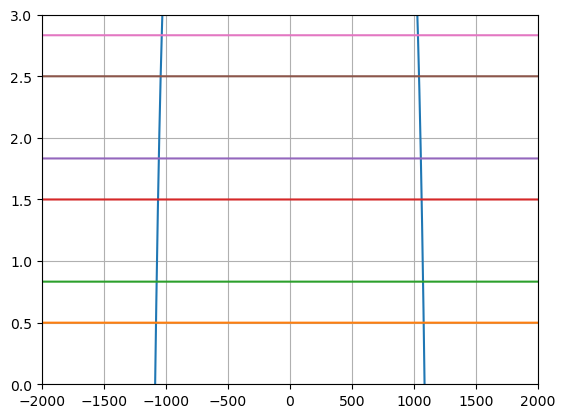

In [232]:
plt.plot(vx, v_mu[-1]/omB-vU/omB)
plt.ylim(0,3)
plt.xlim(-2000,2000)

plt.plot(vx, np.ones(len(vx))*.5)
plt.plot(vx, np.ones(len(vx))*.5+.333)

plt.plot(vx, np.ones(len(vx))*1.5)
plt.plot(vx, np.ones(len(vx))*1.5+.333)

plt.plot(vx, np.ones(len(vx))*2.5)
plt.plot(vx, np.ones(len(vx))*2.5+.333)






plt.grid()



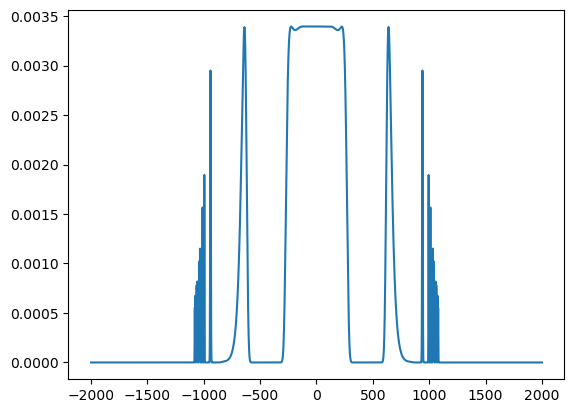

In [233]:
plt.plot(vx, dnum_e)

(0.0, 7.0)

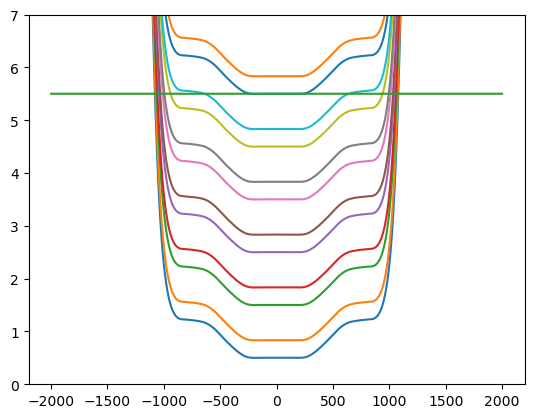

In [234]:
plt.plot(vx, vU/omB+.5)
plt.plot(vx, vU/omB+.5+.333)

plt.plot(vx, vU/omB+1.5)
plt.plot(vx, vU/omB+1.5+.333)

plt.plot(vx, vU/omB+2.5)
plt.plot(vx, vU/omB+2.5+.333)

plt.plot(vx, vU/omB+3.5)
plt.plot(vx, vU/omB+3.5+.333)

plt.plot(vx, vU/omB+4.5)
plt.plot(vx, vU/omB+4.5+.333)

plt.plot(vx, vU/omB+5.5)
plt.plot(vx, vU/omB+5.5+.333)
plt.plot(vx, np.ones(len(vx))*v_mu[-1]/omB)

plt.ylim(0,7)

In [235]:
mu_print = v_mu[-1]

header = f"""Data file for U(x)
mu = {mu_print}
omB = {omB}
Columns:
1) x
2) U(x)
3) local density n_e(x)
4) compressibility dn_e(x)
"""

np.savetxt(
    "Ux.dat",
    np.column_stack([vx, vU, vnum_e, dnum_e]),
    header=header,
    fmt="%.8e",
    comments="# "
)